# Banking Customer Churn classification using logistic Regression

## Importing Libraries 

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


## Loading Dataset

In [20]:
df=pd.read_csv('Bank_Customer_Churn_Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


###
'customer_id': The customer's ID.

'credit_score': A numerical representation of a customer's creditworthiness.

'country': The customer's country of residence.

'gender': The gender of the customer.

'age': The age of the customer.

'tenure': The time the client has spent with the company.

'balance': The customer's account balance.

'products_number': The number of products the customer has in the company.

'credit_card': Indicates whether the customer has a credit card with the company.

'active_member': Indicates whether the customer is an active member of the company.

'estimate_salary': The customer's estimated salary.

'churn': Indicates whether the client is churning. 1 indicates that the customer is shaking, 0 indicates that he is not.

## Checking size of dataset

In [21]:
df.shape


(10000, 12)

## Checking datatypes and null values

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


## Checking Statistical data

In [23]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Checking NULL values

In [24]:
df.isna().sum()


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

## Checking  Duplicate row

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
x = pd.DataFrame(df.groupby(['churn'])['churn'].count())
x

,churn
churn,
0,7963
1,2037


## Analysing data (EDA)

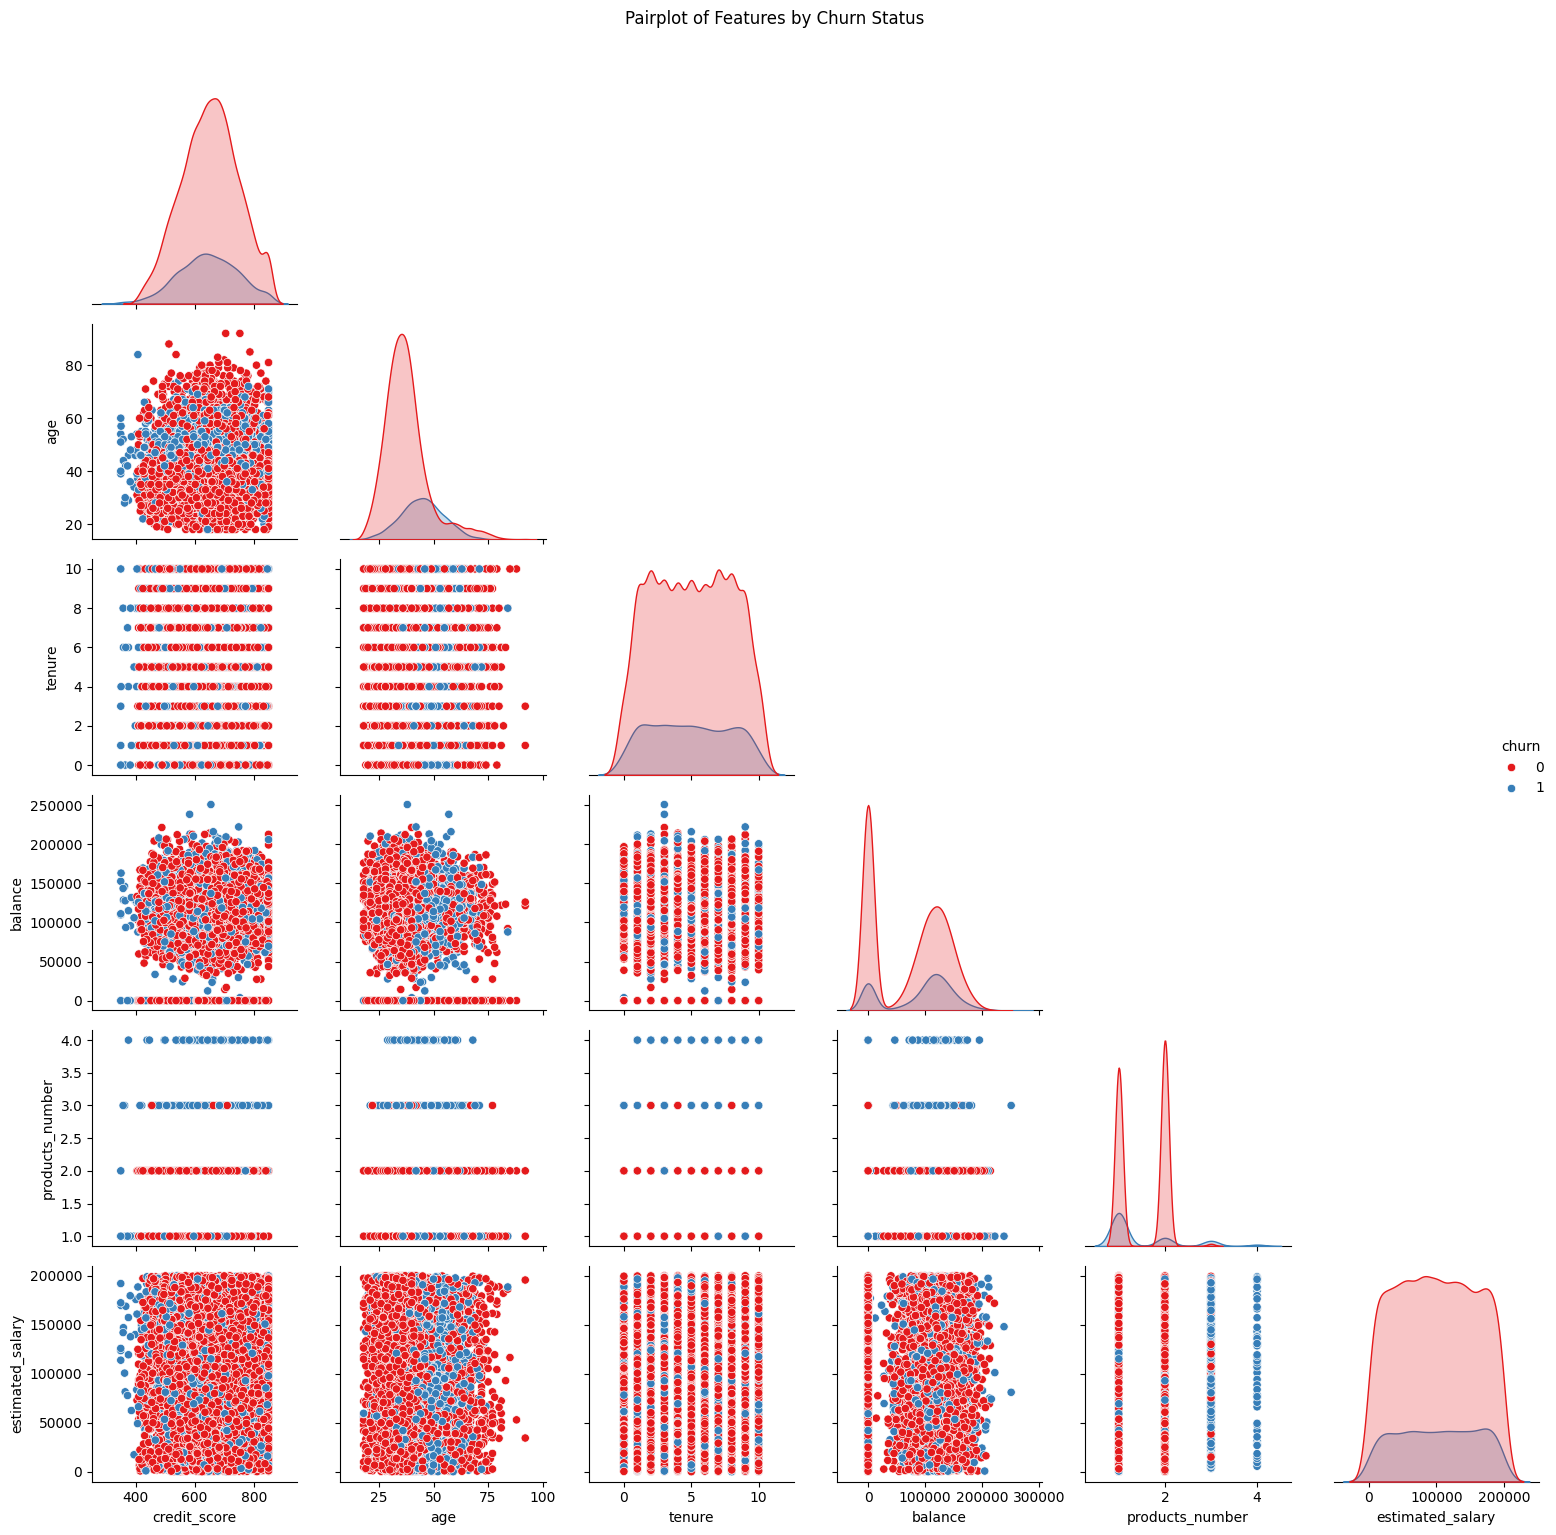

In [27]:
numerical_features = ['credit_score', 'age', 'tenure', 'balance', 
                      'products_number', 'estimated_salary', 'churn']

sns.pairplot(df[numerical_features], hue='churn', diag_kind='kde', 
             palette='Set1', corner=True)


plt.suptitle('Pairplot of Features by Churn Status', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_20544\3112822722.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='Set1')


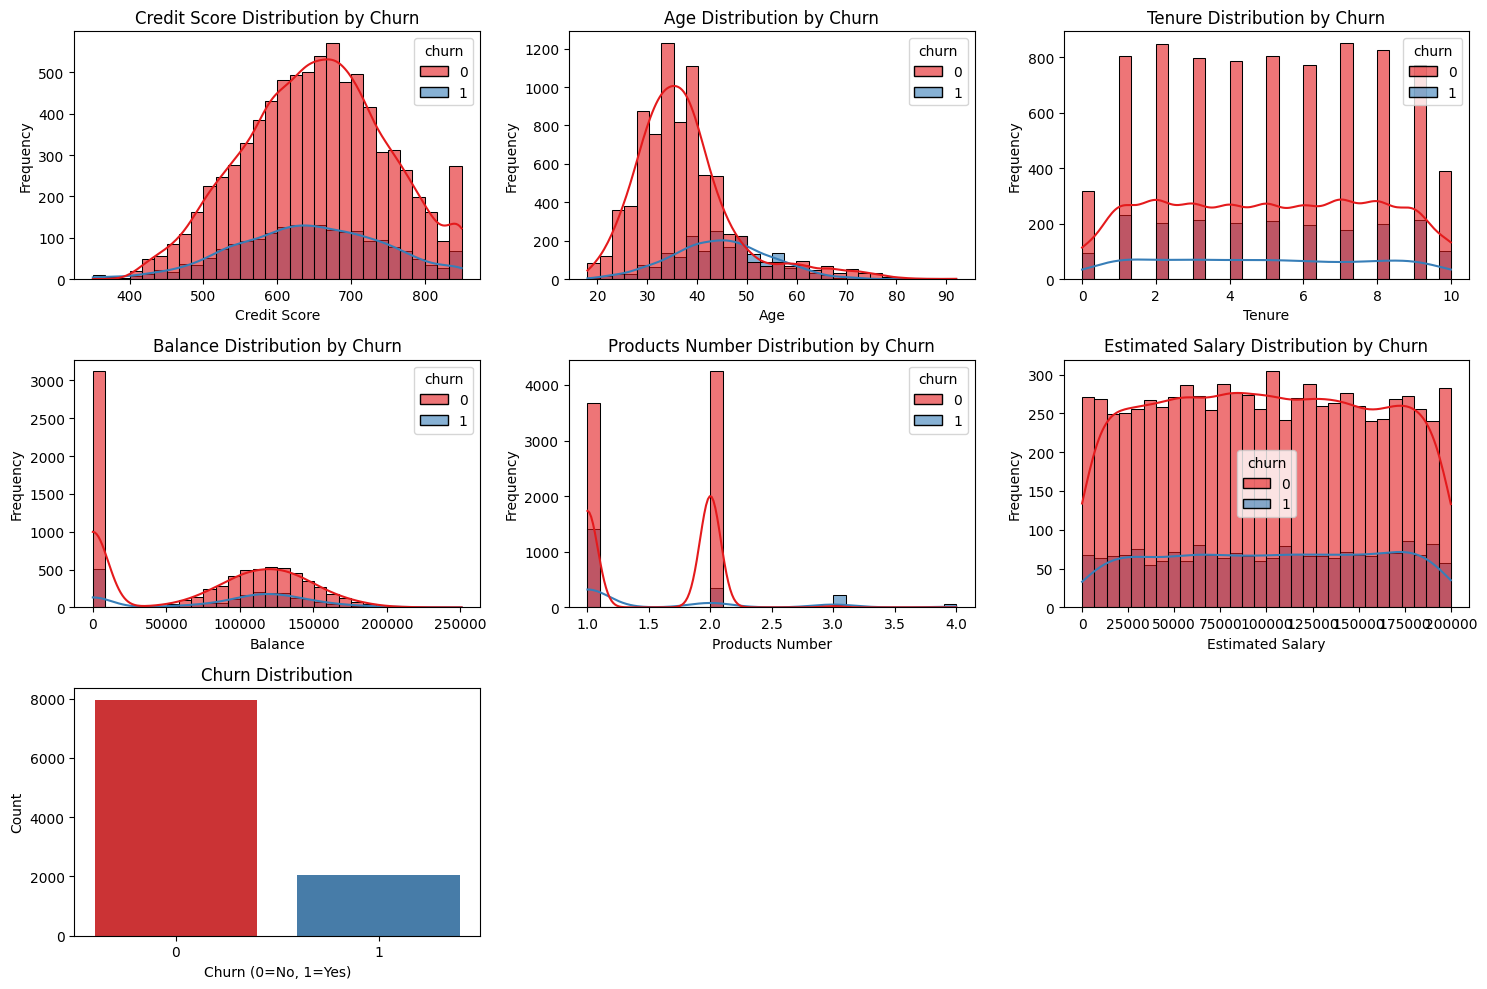

In [28]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
 
    
    plt.subplot(3, 3, i + 1)
  
    if feature != 'churn':
       
        
        sns.histplot(data=df, x=feature, hue='churn', bins=30, 
                     alpha=0.6, kde=True, palette='Set1')
        
        
        plt.title(f'{feature.replace("_", " ").title()} Distribution by Churn')

        
        plt.xlabel(feature.replace("_", " ").title())
        
        
        plt.ylabel('Frequency')
       
    else:
      
        sns.countplot(data=df, x='churn', palette='Set1')
        
        plt.title('Churn Distribution')
        plt.xlabel('Churn (0=No, 1=Yes)')
        plt.ylabel('Count')

plt.tight_layout()


## Splitting training and test data

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop(['customer_id', 'churn'], axis=1) 
y = df['churn']               
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
9254,686,France,Male,32,6,0.00,2,1,1,179093.26
1561,632,Germany,Male,42,4,119624.60,2,1,1,195978.86
1670,559,Spain,Male,24,3,114739.92,1,1,0,85891.02
6087,561,France,Female,27,9,135637.00,1,1,0,153080.40
6669,517,France,Male,56,9,142147.32,1,0,0,39488.04


In [30]:
df['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

## Column Transformer for converting categorical to numerical values

In [67]:

trf1=ColumnTransformer([
    ("age_country",OneHotEncoder(sparse_output=False, drop='first'),[1,2])
    
],remainder='passthrough')



## Column Transformer for scaling data

In [77]:
trf2=ColumnTransformer([
    ('scaled',StandardScaler(),slice(0,12))
],remainder='passthrough')

## Column Transfromer to chose best features

In [78]:
# we dont use chi here because it doesnt work with negativw values but f_classif works fine with negative values too
trf3 = SelectKBest(score_func=f_classif)

In [94]:
# function for choosing models for testing
models = {
    "RandomForest": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}



In [95]:
# Funstionn for makeing pipe fitting models and doing evaluation
def evaluate_model(name, model, X_train, y_train, X_test, y_test, trf1, trf2, trf3):
    
    # Build pipeline
    pipe = Pipeline([
        ('trf1', trf1),
        ('trf2', trf2),
        ('trf3', trf3),
        ('model', model)
    ])
    
    # Cross Validation

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f"\n{name}")
    print("Cross-Validation Accuracy:", np.mean(cv_scores))
    
    # Train + Test Metrics
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))


## Calling pipeline to fit and do evaluation

In [96]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test, trf1, trf2, trf3)



RandomForest
Cross-Validation Accuracy: 0.85925
Test Accuracy: 0.867
Precision: 0.7550200803212851
Recall: 0.47837150127226463
F1 Score: 0.5856697819314641

LogisticRegression
Cross-Validation Accuracy: 0.810375
Test Accuracy: 0.812
Precision: 0.5594405594405595
Recall: 0.2035623409669211
F1 Score: 0.29850746268656714

SVM
Cross-Validation Accuracy: 0.854875
Test Accuracy: 0.86
Precision: 0.775609756097561
Recall: 0.40458015267175573
F1 Score: 0.5317725752508361


## Using Grip Search CV

In [98]:
param_grid = [

    # 🔹 Random Forest
    {
        'model': [RandomForestClassifier()],
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20]
    },

    # 🔹 Logistic Regression
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': [0.1, 1, 10],
        'model__solver': ['liblinear']
    },

    # 🔹 SVM
    {
        'model': [SVC()],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    }
]


In [99]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [RandomForestClassifier()], 'model__max_depth': [None, 10, ...], 'model__n_estimators': [100, 200]}, {'model': [LogisticRegre...max_iter=1000)], 'model__C': [0.1, 1, ...], 'model__solver': ['liblinear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intCont

In [100]:
print("Best Model:", grid.best_estimator_)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Model: Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('age_country',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [1, 2])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaled', StandardScaler(),
                                                  slice(0, 12, None))])),
                ('trf3', SelectKBest()),
                ('model', RandomForestClassifier(max_depth=10))])
Best Parameters: {'model': RandomForestClassifier(), 'model__max_depth': 10, 'model__n_estimators': 100}
Best CV Score: 0.8651249999999999


In [101]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))


Test Accuracy: 0.8615
